# Proyecto Final — Pre-entrega 2
## Análisis Exploratorio de Datos

**Tema:** Diseño de completación de pozos horizontales no convencionales en la Cuenca Neuquina
(Vaca Muerta)

**Integrantes del grupo:** Franco Malacalza · Martín Gerbaldo · Carolina

**Comisión / Tutora:** EnergIA Digital — Data Science, Tutora Belén

**Fecha de entrega:** 25/09/2026

---

## 1. Objetivo del proyecto

### Pregunta de negocio

Cada pozo horizontal no convencional se termina con un diseño de fractura hidráulica: una longitud
de rama lateral, una cantidad de etapas, un volumen de arena y de agua bombeados a determinada
presión. Ese diseño concentra buena parte del costo de la terminación, y las operadoras deciden
cuánto invertir en él sin certeza de cuánto va a producir el pozo después.

**¿Cómo se diseña hoy un pozo no convencional en Vaca Muerta, cómo cambió ese diseño en el tiempo,
y cuánto de la productividad se explica por esas decisiones?**

### Alcance de esta pre-entrega

La consigna de la Pre-entrega 2 pide **elegir tema y dataset, describir el objetivo, explorar y
transformar los datos con Pandas y visualizarlos**. Este notebook cubre exactamente eso sobre la
tabla de fracturas, y deja construido el dataset analítico que alimentará el modelado.

| Etapa | Entrega | Estado |
|---|---|---|
| Exploración, limpieza, transformación y visualización | Pre-entrega 2 | **este notebook** |
| Modelo supervisado (regresión / clasificación) | Pre-entrega 3 | pendiente |
| Modelo no supervisado (clustering de arquetipos de diseño) | Pre-entrega 4 | pendiente |

### Objetivo predictivo (Pre-entrega 3)

Estimar la **producción acumulada de petróleo en los primeros 12 meses** de un pozo a partir de las
características de su completación y su ubicación geológica.

- **Tipo de problema:** regresión, sobre la variable continua `prod_pet_acum_12m` (m³)
- **Variante de clasificación:** predecir si el pozo cae en el cuartil superior de productividad de
  su formación (`top_tier`)

La sección 11 de este notebook construye esa variable objetivo y es **opcional**: se activa sola si
los archivos de producción están descargados. El resto del notebook corre completo sin ellos.

### Objetivo no supervisado (Pre-entrega 4)

Clustering sobre las variables de completación para identificar **arquetipos de diseño de pozo**, y
comparación del rendimiento productivo entre grupos.

### Fuentes de datos

Portal de datos abiertos de la Secretaría de Energía de la Nación.

| Dataset | Grano | Registros | Uso |
|---|---|---|---|
| Datos de fractura de pozos de hidrocarburos (Adjunto IV) | Una operación de fractura | 4.890 | Tabla base |
| Producción de petróleo y gas por pozo (Capítulo IV) | Un pozo por mes | millones | Variable objetivo (opcional) |

Se vinculan por el identificador de pozo `idpozo`.

---

## 2. Configuración del entorno

Todo el análisis se hace con **Pandas**, como pide la consigna. Matplotlib y Seaborn se usan
únicamente para dibujar.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
HOY = pd.Timestamp.today().normalize()

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.4.6


## 3. Carga de los datos

El archivo del Adjunto IV se descarga del portal de datos abiertos de la Secretaría de Energía. Es
la versión de actualización diaria, así que incluye operaciones registradas hasta la fecha de
descarga.

La función `localizar` busca el archivo en las ubicaciones habituales (carpeta actual, `data/`,
Colab, Google Drive) y, si no lo encuentra y estamos en Colab, ofrece subirlo a mano.

In [2]:
PATRON_FRACTURA = "*fractura*adjunto-iv*.csv"

CARPETAS_BUSQUEDA = [".", "data", "/content", "/content/data",
                     "/content/drive/MyDrive", "/content/drive/MyDrive/data"]


def localizar(patron, carpetas=CARPETAS_BUSQUEDA):
    """Devuelve la primera ruta que coincide con el patrón, o None."""
    for carpeta in carpetas:
        encontrados = sorted(glob.glob(str(Path(carpeta) / patron)))
        if encontrados:
            return encontrados[0]
    return None


ruta_fractura = localizar(PATRON_FRACTURA)

if ruta_fractura is None:
    try:
        from google.colab import files
        print("No encontré el CSV de fractura. Subilo ahora (pesa ~1,2 MB):")
        subidos = files.upload()
        ruta_fractura = list(subidos)[0]
    except ImportError:
        raise FileNotFoundError(
            f"No se encontró ningún archivo que coincida con '{PATRON_FRACTURA}'.\n"
            f"Carpetas revisadas: {CARPETAS_BUSQUEDA}\n"
            "Descargalo de http://datos.energia.gob.ar/dataset/datos-de-fractura-de-pozos-adjunto-iv"
        )

print(f"Archivo: {ruta_fractura}")
frac = pd.read_csv(ruta_fractura, low_memory=False)

print(f"Registros:    {len(frac):,}")
print(f"Columnas:     {frac.shape[1]}")
print(f"Pozos únicos: {frac['idpozo'].nunique():,}")
frac.head()

Archivo: data/datos-de-fractura-de-pozos-de-hidrocarburos-adjunto-iv-actualizacin-diaria.csv
Registros:    4,890
Columnas:     30
Pozos únicos: 4,646


,id_base_fractura_adjiv,idpozo,sigla,cuenca,areapermisoconcesion,yacimiento,formacion_productiva,tipo_reservorio,subtipo_reservorio,longitud_rama_horizontal_m,cantidad_fracturas,tipo_terminacion,arena_bombeada_nacional_tn,arena_bombeada_importada_tn,agua_inyectada_m3,co2_inyectado_m3,presion_maxima_psi,potencia_equipos_fractura_hp,fecha_inicio_fractura,fecha_fin_fractura,fecha_data,anio_if,mes_if,anio_ff,mes_ff,anio_carga,mes_carga,empresa_informante,mes,anio
0,30,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.00,3,Punzado,0.00,0.00,"2,718.20",0.00,"10,190.00","10,897.00",2019-04-20,2019-04-30,2019-06-14 17:13:03.68279,2019,4,2019,4,2019,6,CAPEX S.A.,4,2019
1,31,159910,APS.Nq.ADC.xp-1033,NEUQUINA,AGUA DEL CAJON,AGUA DEL CAJON,los molles,NO CONVENCIONAL,SHALE,0.00,1,Punzado,0.00,0.00,600.00,0.00,"9,250.00","10,251.00",2018-11-02,2018-11-03,2019-06-14 17:14:19.179874,2018,11,2018,11,2019,6,CAPEX S.A.,11,2018
2,37,159219,YPF.Nq.AdlA-1001(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,"1,437.30",18,Tapón disparo,"3,761.37",536.85,"25,768.30",0.00,"15,000.00","32,000.00",2017-11-19,2017-12-14,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
3,38,159220,YPF.Nq.AdlA-1002(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,"1,518.30",19,Tapón disparo,"3,903.70",558.23,"27,398.37",0.00,"11,348.00","32,000.00",2017-11-21,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017
4,39,159221,YPF.Nq.AdlA-1003(h),NEUQUINA,AGUADA DE LA ARENA,AGUADA DE LA ARENA,vaca muerta,NO CONVENCIONAL,SHALE,"1,482.30",19,Tapón disparo,"3,949.02",569.92,"27,157.60",0.00,"11,076.00","32,000.00",2017-11-18,2017-12-15,2019-06-27 13:46:21.14935,2017,11,2017,12,2019,6,YPF S.A.,11,2017


In [3]:
frac.info()

<class 'pandas.DataFrame'>
RangeIndex: 4890 entries, 0 to 4889
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_base_fractura_adjiv        4890 non-null   int64  
 1   idpozo                        4890 non-null   int64  
 2   sigla                         4890 non-null   str    
 3   cuenca                        4890 non-null   str    
 4   areapermisoconcesion          4890 non-null   str    
 5   yacimiento                    4890 non-null   str    
 6   formacion_productiva          4890 non-null   str    
 7   tipo_reservorio               4855 non-null   str    
 8   subtipo_reservorio            3916 non-null   str    
 9   longitud_rama_horizontal_m    4890 non-null   float64
 10  cantidad_fracturas            4890 non-null   int64  
 11  tipo_terminacion              4890 non-null   str    
 12  arena_bombeada_nacional_tn    4890 non-null   float64
 13  arena_bombeada

### 3.1 Diccionario de variables

| Columna | Rol | Descripción |
|---|---|---|
| `idpozo` | Identificador | Clave de vínculo con la tabla de producción |
| `sigla` | Identificador | Nombre del pozo según la operadora |
| `cuenca`, `areapermisoconcesion`, `yacimiento` | Dimensión | Ubicación geográfica y administrativa |
| `formacion_productiva` | Dimensión | Formación geológica objetivo |
| `tipo_reservorio`, `subtipo_reservorio` | Dimensión | Convencional / no convencional, shale / tight |
| `tipo_terminacion` | Dimensión | Técnica de terminación aplicada |
| `empresa_informante` | Dimensión | Operadora que reporta |
| `longitud_rama_horizontal_m` | Métrica | Longitud de la rama lateral |
| `cantidad_fracturas` | Métrica | Etapas de fractura ejecutadas |
| `arena_bombeada_nacional_tn`, `arena_bombeada_importada_tn` | Métrica | Agente de sostén bombeado |
| `agua_inyectada_m3`, `co2_inyectado_m3` | Métrica | Fluido de fractura |
| `presion_maxima_psi`, `potencia_equipos_fractura_hp` | Métrica | Condiciones de operación |
| `fecha_inicio_fractura`, `fecha_fin_fractura` | Temporal | Ventana de ejecución |
| `anio_if`, `mes_if`, `anio_ff`, `mes_ff` | Temporal | Descomposición de las fechas |

**No existe una columna `provincia`.** La ubicación se maneja con `cuenca`, `yacimiento` y
`areapermisoconcesion`.

## 4. Exploración inicial: estructura y grano

Antes de mirar cualquier distribución hay que responder tres preguntas: qué representa cada fila,
cuál es la clave primaria, y si esa clave es realmente única.

In [4]:
n_filas = len(frac)
n_pozos = frac["idpozo"].nunique()

print(f"Filas:         {n_filas:,}")
print(f"Pozos únicos:  {n_pozos:,}")
print(f"Diferencia:    {n_filas - n_pozos:,} registros excedentes")
print()
print("El grano NO es un pozo por fila: hay pozos con varias operaciones registradas.")

Filas:         4,890
Pozos únicos:  4,646
Diferencia:    244 registros excedentes

El grano NO es un pozo por fila: hay pozos con varias operaciones registradas.


In [5]:
repetidos = frac[frac.duplicated("idpozo", keep=False)]
print(f"Registros involucrados: {len(repetidos):,} en {repetidos['idpozo'].nunique():,} pozos")
print()

ejemplo = repetidos["idpozo"].value_counts().idxmax()
columnas_muestra = ["idpozo", "sigla", "fecha_inicio_fractura", "longitud_rama_horizontal_m",
                    "cantidad_fracturas", "arena_bombeada_nacional_tn", "agua_inyectada_m3"]
repetidos[repetidos["idpozo"] == ejemplo][columnas_muestra]

Registros involucrados: 427 en 183 pozos



,idpozo,sigla,fecha_inicio_fractura,longitud_rama_horizontal_m,cantidad_fracturas,arena_bombeada_nacional_tn,agua_inyectada_m3
825,159341,APS.Nq.Sa-1238,2018-05-28,0.00,5,0.00,396.40
2346,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,76.00
2347,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,50.00
2348,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,90.00
2349,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,130.00
2350,159341,APS.Nq.Sa-1238,2018-05-28,0.00,1,0.00,125.00


> **Hallazgo 1 — el grano no es un pozo por fila.**
>
> Los registros repetidos comparten pozo **y fecha de fractura**, y reparten las etapas entre varias
> filas. Son **cargas parciales de una misma operación de fractura**, no refracturas independientes.
>
> Eso define cómo consolidarlos en la sección 7: las magnitudes aditivas (etapas, arena, agua) se
> suman, y las propiedades del pozo (longitud de rama, presión máxima) se toman una sola vez.

## 5. Perfilado de columnas

Un perfil por columna: tipo, nulos, **ceros**, cardinalidad y valor más frecuente. Los ceros se
miran explícitamente porque en este dataset son el problema real, no los nulos.

In [6]:
def perfilar(df):
    """Perfil compacto: tipo, nulos, ceros, cardinalidad y valor más frecuente."""
    filas = []
    for col in df.columns:
        serie = df[col]
        n_nulos = serie.isna().sum()
        n_ceros = (serie == 0).sum() if pd.api.types.is_numeric_dtype(serie) else 0
        moda = serie.mode(dropna=True)
        filas.append({
            "columna": col,
            "tipo": str(serie.dtype),
            "nulos": n_nulos,
            "%_nulos": round(100 * n_nulos / len(df), 1),
            "ceros": n_ceros,
            "%_ceros": round(100 * n_ceros / len(df), 1),
            "únicos": serie.nunique(dropna=True),
            "más_frecuente": moda.iloc[0] if len(moda) else None,
        })
    return pd.DataFrame(filas)


perfil = perfilar(frac).sort_values("%_ceros", ascending=False).reset_index(drop=True)
perfil

,columna,tipo,nulos,%_nulos,ceros,%_ceros,únicos,más_frecuente
0,co2_inyectado_m3,float64,0,0.00,4731,96.70,132,0.00
1,arena_bombeada_importada_tn,float64,0,0.00,2348,48.00,2168,0.00
2,longitud_rama_horizontal_m,float64,0,0.00,2054,42.00,1928,0.00
3,arena_bombeada_nacional_tn,float64,0,0.00,1565,32.00,3236,0.00
4,agua_inyectada_m3,float64,0,0.00,305,6.20,4255,0.00
5,potencia_equipos_fractura_hp,float64,51,1.00,154,3.10,1795,"40,000.00"
6,presion_maxima_psi,float64,0,0.00,78,1.60,3496,0.00
7,areapermisoconcesion,str,0,0.00,0,0.00,106,LOMA CAMPANA
8,cuenca,str,0,0.00,0,0.00,3,NEUQUINA
9,formacion_productiva,str,0,0.00,0,0.00,28,vaca muerta


El perfilado deja a la vista dos cosas.

**Los nulos casi no existen, pero los ceros son masivos.** `longitud_rama_horizontal_m` vale cero en
más del 40% de los registros. Un cero en longitud de rama no es un dato faltante: es un **pozo
vertical**.

**`co2_inyectado_m3` es cero en el 96,7% de los registros**, la proporción más alta del dataset. Vale
la pena averiguar dónde está ese 3,3% restante antes de decidir qué hacer con la columna.

In [7]:
con_co2 = frac[frac["co2_inyectado_m3"] > 0]

print(f"Registros con CO2 > 0: {len(con_co2)}")
print(f"  de los cuales horizontales: {(con_co2['longitud_rama_horizontal_m'] > 0).sum()}")
print(f"  de los cuales verticales:   {(con_co2['longitud_rama_horizontal_m'] == 0).sum()}")
print()
print(f"Años en que se usó: {con_co2['anio_if'].min()} a {con_co2['anio_if'].max()}")

Registros con CO2 > 0: 159
  de los cuales horizontales: 0
  de los cuales verticales:   159

Años en que se usó: 2010 a 2022


La fractura con CO2 aparece en **159 registros y todos son pozos verticales**, entre 2010 y 2022.
Ningún pozo horizontal del dataset la usó.

Dentro de la población que vamos a analizar la columna es entonces **idénticamente cero** y no aporta
información. Se elimina en la sección 7, después de aplicar el filtro. Vale notar que mirando solo el
porcentaje de ceros global la conclusión habría sido otra.

### 5.1 El dataset mezcla pozos verticales y horizontales

In [8]:
frac["es_horizontal"] = frac["longitud_rama_horizontal_m"] > 0

comparacion = frac.groupby("es_horizontal").agg(
    registros=("idpozo", "size"),
    etapas_mediana=("cantidad_fracturas", "median"),
    arena_mediana=("arena_bombeada_nacional_tn", "median"),
    agua_mediana=("agua_inyectada_m3", "median"),
)
comparacion.index = ["Verticales", "Horizontales"]
comparacion

,registros,etapas_mediana,arena_mediana,agua_mediana
Verticales,2054,3.00,0.00,429.80
Horizontales,2836,38.00,"8,576.15","54,313.60"


In [9]:
pd.crosstab(frac["tipo_reservorio"],
            frac["es_horizontal"].map({True: "Horizontal", False: "Vertical"}),
            dropna=False)

es_horizontal,Horizontal,Vertical
tipo_reservorio,,
CONVENCIONAL,72,861
NO CONVENCIONAL,2744,1177
NO DISCRIMINADO,1,0
NaN,19,16


> **Hallazgo 2 — el dataset mezcla dos poblaciones incomparables.**
>
> Un pozo vertical mediano bombea **cero toneladas de arena** y unos 430 m³ de agua, con 3 etapas.
> Uno horizontal mediano bombea más de 8.500 toneladas, 54.000 m³ de agua y 38 etapas. Son
> operaciones de una escala completamente distinta, y el cruce con `tipo_reservorio` lo confirma:
> los verticales son mayoritariamente convencionales y los horizontales, no convencionales.
>
> **Decisión metodológica:** el análisis se restringe a pozos horizontales. Incluir los verticales
> generaría un modelo que aprende a distinguir vertical de horizontal en lugar de aprender el efecto
> del diseño de completación, y las variables de intensidad por metro serían indefinidas (división
> por cero).

## 6. Calidad de datos

### 6.1 Reglas de negocio

Se chequea contra el conocimiento del dominio: fechas coherentes, sin valores negativos en
magnitudes físicas, y sin ceros en variables que físicamente no pueden valer cero.

In [10]:
horiz = frac[frac["es_horizontal"]].copy()

for col in ["fecha_inicio_fractura", "fecha_fin_fractura", "fecha_data"]:
    horiz[col] = pd.to_datetime(horiz[col], errors="coerce")

numericas = ["longitud_rama_horizontal_m", "cantidad_fracturas",
             "arena_bombeada_nacional_tn", "arena_bombeada_importada_tn",
             "agua_inyectada_m3", "presion_maxima_psi",
             "potencia_equipos_fractura_hp"]

problemas = {
    "Fecha de fin anterior a la de inicio":
        (horiz["fecha_fin_fractura"] < horiz["fecha_inicio_fractura"]).sum(),
    "Fecha de fractura posterior a hoy":
        (horiz["fecha_inicio_fractura"] > HOY).sum(),
    "Presión máxima igual a cero":
        (horiz["presion_maxima_psi"] == 0).sum(),
    "Potencia de equipos igual a cero":
        (horiz["potencia_equipos_fractura_hp"] == 0).sum(),
    "Potencia de equipos nula":
        horiz["potencia_equipos_fractura_hp"].isna().sum(),
    "Agua inyectada igual a cero":
        (horiz["agua_inyectada_m3"] == 0).sum(),
    "Arena total igual a cero":
        ((horiz["arena_bombeada_nacional_tn"] + horiz["arena_bombeada_importada_tn"]) == 0).sum(),
    "Valores negativos en variables físicas":
        int((horiz[numericas] < 0).sum().sum()),
}

pd.Series(problemas, name="registros").to_frame()

,registros
Fecha de fin anterior a la de inicio,34
Fecha de fractura posterior a hoy,3
Presión máxima igual a cero,3
Potencia de equipos igual a cero,44
Potencia de equipos nula,51
Agua inyectada igual a cero,3
Arena total igual a cero,0
Valores negativos en variables físicas,0


Ningún valor negativo y ningún pozo horizontal sin arena, que es buena señal sobre la carga.

Los ceros en presión, potencia y agua sí son **faltantes disfrazados**: un equipo de fractura no
opera a cero psi ni bombea cero metros cúbicos de fluido. Aparecen además fechas de fractura
posteriores a hoy y fechas de fin anteriores a las de inicio, que solo pueden ser errores de carga.

### 6.2 Longitudes de rama implausibles

La rama horizontal tiene una cola inferior sospechosa que conviene mirar antes de aceptarla.

In [11]:
cola_baja = horiz.loc[horiz["longitud_rama_horizontal_m"] < 800, "longitud_rama_horizontal_m"]

print(f"Pozos con rama menor a 800 m: {len(cola_baja)}")
print()
print(cola_baja.describe(percentiles=[.1, .25, .5, .75]))
print()
print("Valores más frecuentes en esa cola:")
print(cola_baja.value_counts().head(8))

Pozos con rama menor a 800 m: 247

count   247.00
mean    112.39
std     210.64
min       0.60
10%       3.00
25%       3.00
50%      15.00
75%      72.50
max     792.00
Name: longitud_rama_horizontal_m, dtype: float64

Valores más frecuentes en esa cola:


longitud_rama_horizontal_m
3.00     63
5.00      6
4.00      5
0.80      4
8.00      4
6.00      4
11.00     4
65.00     3
Name: count, dtype: int64


> **Hallazgo 3 — hay un valor centinela en la longitud de rama.**
>
> El valor **3,0 metros se repite 63 veces**. Una rama lateral de tres metros no existe físicamente:
> es un valor centinela, no una medición. Lo mismo con los valores de 0,8 a 11 metros.

Para elegir el umbral de corte se hace un **análisis de sensibilidad**: se mira cuántos pozos se
conservan con cada umbral y si el espaciamiento típico entre etapas se mantiene estable. El
espaciamiento es un buen testigo porque es una decisión de ingeniería con un rango físico acotado.

In [12]:
for umbral in [0, 100, 300, 500, 800, 1000]:
    sub = horiz[horiz["longitud_rama_horizontal_m"] >= umbral]
    espaciamiento = (sub["longitud_rama_horizontal_m"] / sub["cantidad_fracturas"]).median()
    intensidad_max = (sub["arena_bombeada_nacional_tn"] / sub["longitud_rama_horizontal_m"]).max()
    print(f"rama >= {umbral:5d} m  ->  {len(sub):5,} registros ({100*len(sub)/len(horiz):5.1f}%)"
          f"  |  espaciamiento mediano {espaciamiento:5.1f} m"
          f"  |  arena/m máxima {intensidad_max:8.1f} tn")

rama >=     0 m  ->  2,836 registros (100.0%)  |  espaciamiento mediano  62.3 m  |  arena/m máxima    102.4 tn
rama >=   100 m  ->  2,634 registros ( 92.9%)  |  espaciamiento mediano  63.3 m  |  arena/m máxima      6.7 tn
rama >=   300 m  ->  2,625 registros ( 92.6%)  |  espaciamiento mediano  63.3 m  |  arena/m máxima      6.7 tn
rama >=   500 m  ->  2,616 registros ( 92.2%)  |  espaciamiento mediano  63.3 m  |  arena/m máxima      6.7 tn


rama >=   800 m  ->  2,589 registros ( 91.3%)  |  espaciamiento mediano  63.1 m  |  arena/m máxima      6.7 tn
rama >=  1000 m  ->  2,544 registros ( 89.7%)  |  espaciamiento mediano  62.8 m  |  arena/m máxima      6.7 tn


**Decisión:** umbral mínimo de **500 metros**. El espaciamiento mediano se estabiliza en unos 63 m a
partir de 100 m de rama y se mantiene ahí, mientras que sin filtro aparece una intensidad máxima de
102 toneladas de arena por metro de rama: unas 25 veces el valor típico, físicamente inviable. Se
elige 500 m en lugar de 100 m porque conserva prácticamente los mismos pozos (92,2% contra 92,9%) y
descarta con más margen la zona donde la longitud reportada no es confiable.

### 6.3 Outliers en las variables de operación

Se usa el criterio del rango intercuartílico (IQR), ignorando los ceros para que no distorsionen los
cuartiles.

In [13]:
def resumen_outliers_iqr(df, columnas, factor=1.5):
    filas = []
    for col in columnas:
        serie = df[col].replace(0, np.nan).dropna()
        q1, q3 = serie.quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - factor * iqr, q3 + factor * iqr
        fuera = ((serie < inferior) | (serie > superior)).sum()
        filas.append({
            "variable": col,
            "outliers": int(fuera),
            "%": round(100 * fuera / len(serie), 1),
            "límite_sup": round(superior, 1),
            "máximo_observado": round(serie.max(), 1),
        })
    return pd.DataFrame(filas).sort_values("%", ascending=False)


resumen_outliers_iqr(horiz, numericas)

,variable,outliers,%,límite_sup,máximo_observado
5,presion_maxima_psi,365,12.90,"13,437.00","209,640.60"
3,arena_bombeada_importada_tn,73,9.70,"2,706.50","80,652.00"
0,longitud_rama_horizontal_m,213,7.50,"4,632.30","5,114.10"
1,cantidad_fracturas,19,0.70,85.00,105.00
2,arena_bombeada_nacional_tn,4,0.20,"20,275.40","20,834.00"
4,agua_inyectada_m3,7,0.20,"134,915.90","537,184.60"
6,potencia_equipos_fractura_hp,1,0.00,"67,717.70","232,159.30"


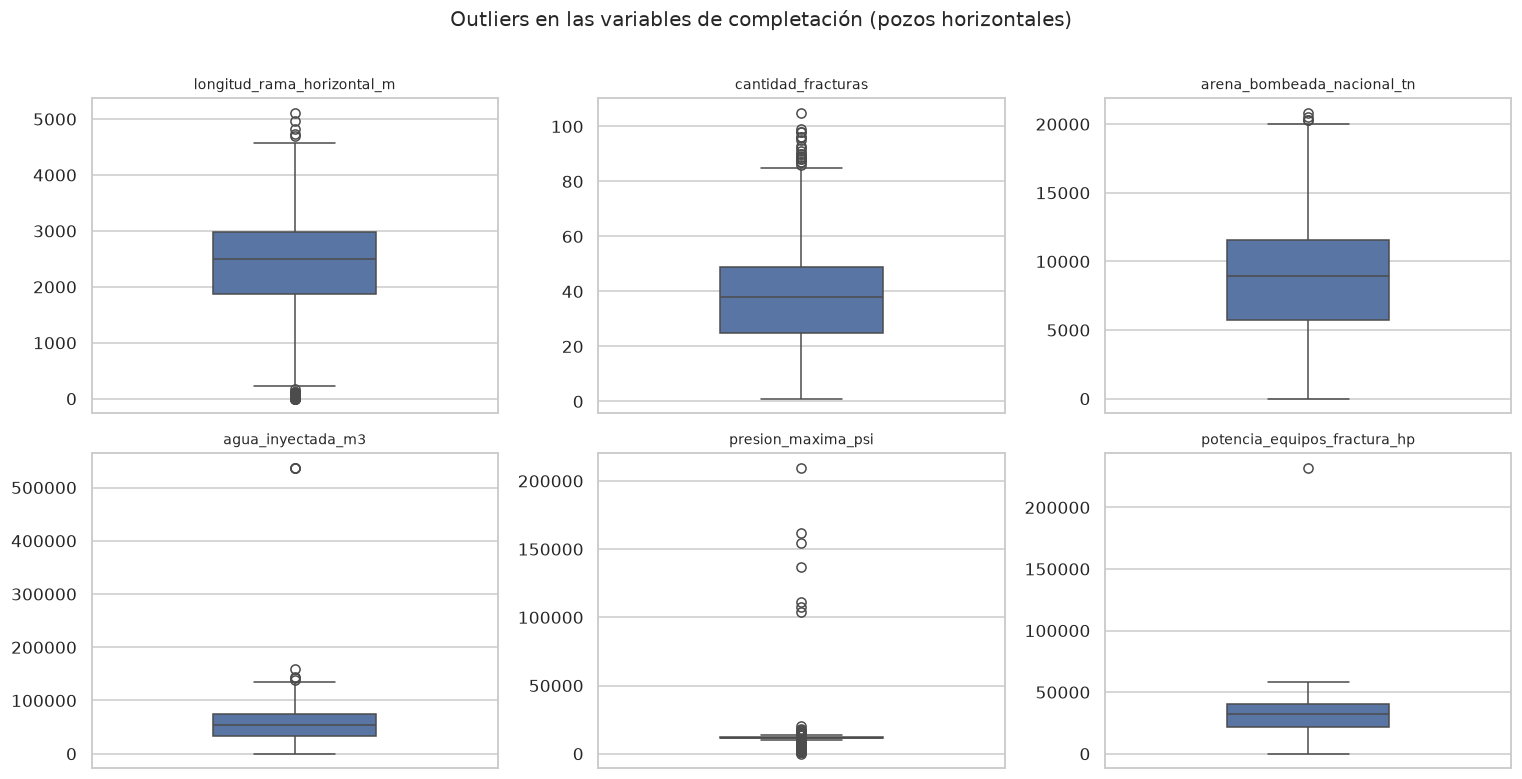

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
variables_grafico = ["longitud_rama_horizontal_m", "cantidad_fracturas",
                     "arena_bombeada_nacional_tn", "agua_inyectada_m3",
                     "presion_maxima_psi", "potencia_equipos_fractura_hp"]

for ax, col in zip(axes.ravel(), variables_grafico):
    sns.boxplot(y=horiz[col].replace(0, np.nan), ax=ax, color="#4C72B0", width=0.4)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")

fig.suptitle("Outliers en las variables de completación (pozos horizontales)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

La presión máxima llega a **209.640 psi** y la potencia a **232.159 hp**. Ambos exceden por más de un
orden de magnitud lo físicamente razonable en una operación de fractura (una fractura típica opera
entre 5.000 y 15.000 psi).

**Decisión:** se recortan por percentil 1 y 99 (*winsorizing*) en lugar de eliminarse. El resto de las
variables de ese pozo son válidas, y borrar la fila entera perdería información buena por un error de
carga en una sola columna.

## 7. Limpieza y transformación

Criterios adoptados, en orden:

1. **Filtrar a pozos horizontales** con rama de al menos 500 m.
2. **Corregir fechas imposibles** convirtiéndolas a nulo.
3. **Consolidar los registros parciales** por `idpozo`: se suman las magnitudes aditivas y se toma el
   máximo de las propiedades del pozo.
4. **Ceros como faltantes** en presión, potencia y agua, imputados con la mediana de la formación.
5. **Recorte de extremos** por percentil 1 y 99 en presión y potencia.
6. **Normalizar el texto** de las categóricas y etiquetar los faltantes.
7. **Descartar la columna constante** `co2_inyectado_m3`.

In [15]:
UMBRAL_RAMA_M = 500

registros_iniciales = len(frac)
df = frac[frac["longitud_rama_horizontal_m"] >= UMBRAL_RAMA_M].copy()

for col in ["fecha_inicio_fractura", "fecha_fin_fractura"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Fechas imposibles -> nulo
df.loc[df["fecha_fin_fractura"] < df["fecha_inicio_fractura"], "fecha_fin_fractura"] = pd.NaT
df.loc[df["fecha_inicio_fractura"] > HOY, "fecha_inicio_fractura"] = pd.NaT

print(f"Registros originales:               {registros_iniciales:,}")
print(f"Tras filtrar horizontales >= 500 m: {len(df):,}")

Registros originales:               4,890
Tras filtrar horizontales >= 500 m: 2,616


In [16]:
# Consolidación de los registros parciales: un pozo por fila
agregaciones = {
    # Propiedades del pozo: no se suman
    "longitud_rama_horizontal_m": "max",
    "presion_maxima_psi": "max",
    "potencia_equipos_fractura_hp": "max",
    # Magnitudes aditivas de la operación
    "cantidad_fracturas": "sum",
    "arena_bombeada_nacional_tn": "sum",
    "arena_bombeada_importada_tn": "sum",
    "agua_inyectada_m3": "sum",
    # Ventana temporal
    "fecha_inicio_fractura": "min",
    "fecha_fin_fractura": "max",
    # Atributos constantes del pozo
    "sigla": "first",
    "cuenca": "first",
    "areapermisoconcesion": "first",
    "yacimiento": "first",
    "formacion_productiva": "first",
    "tipo_reservorio": "first",
    "subtipo_reservorio": "first",
    "tipo_terminacion": "first",
    "empresa_informante": "first",
}

df = (df.groupby("idpozo")
        .agg(**{col: (col, func) for col, func in agregaciones.items()})
        .reset_index())

print(f"Pozos tras la consolidación: {len(df):,}")

Pozos tras la consolidación: 2,603


In [17]:
# Ceros como faltantes, imputados por mediana de formación
for col in ["presion_maxima_psi", "potencia_equipos_fractura_hp", "agua_inyectada_m3"]:
    n_ceros = (df[col] == 0).sum()
    n_nulos = df[col].isna().sum()
    df[col] = df[col].replace(0, np.nan)
    mediana_formacion = df.groupby("formacion_productiva")[col].transform("median")
    df[col] = df[col].fillna(mediana_formacion).fillna(df[col].median())
    print(f"{col}: {n_ceros} ceros + {n_nulos} nulos imputados por mediana de formación")

print()

# Recorte de extremos físicamente implausibles
for col in ["presion_maxima_psi", "potencia_equipos_fractura_hp"]:
    inferior, superior = df[col].quantile([0.01, 0.99])
    n_recortados = ((df[col] < inferior) | (df[col] > superior)).sum()
    df[col] = df[col].clip(inferior, superior)
    print(f"{col}: {n_recortados} valores recortados al rango [{inferior:,.0f} , {superior:,.0f}]")

print()
print(f"Nulos restantes en variables numéricas: "
      f"{df.select_dtypes('number').isna().sum().sum()}")

presion_maxima_psi: 3 ceros + 0 nulos imputados por mediana de formación
potencia_equipos_fractura_hp: 44 ceros + 0 nulos imputados por mediana de formación
agua_inyectada_m3: 3 ceros + 0 nulos imputados por mediana de formación

presion_maxima_psi: 54 valores recortados al rango [6,600 , 13,846]
potencia_equipos_fractura_hp: 26 valores recortados al rango [2,000 , 44,000]

Nulos restantes en variables numéricas: 0


In [18]:
# Categóricas: normalización de texto y etiquetado explícito de faltantes
categoricas = ["cuenca", "formacion_productiva", "tipo_reservorio",
               "subtipo_reservorio", "tipo_terminacion", "empresa_informante",
               "yacimiento", "areapermisoconcesion"]

for col in categoricas:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace({"nan": "sin dato", "": "sin dato"})

# Constante (idénticamente cero) dentro de la población horizontal: no aporta información
df = df.drop(columns=["co2_inyectado_m3"], errors="ignore")

df[categoricas].nunique().sort_values().to_frame("categorías")

,categorías
cuenca,2
subtipo_reservorio,2
tipo_reservorio,3
tipo_terminacion,5
formacion_productiva,7
empresa_informante,17
areapermisoconcesion,66
yacimiento,74


### 7.1 ¿Qué quedó en el dataset?

Vale la pena mirar la composición antes de seguir, porque condiciona todo lo que viene.

In [19]:
for col in ["cuenca", "formacion_productiva", "subtipo_reservorio", "tipo_terminacion"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().head(5).to_string())
    print()

--- cuenca ---
cuenca
neuquina    2590
austral       13

--- formacion_productiva ---
formacion_productiva
vaca muerta    2517
mulichinco       69
magallanes       12
quintuco          2
lajas             1

--- subtipo_reservorio ---
subtipo_reservorio
shale    2517
tight      75

--- tipo_terminacion ---
tipo_terminacion
tapón disparo          2050
punzado                 425
jetteo                   46
camisas y punzados       44
camisas deslizables      38



El dataset quedó **fuertemente concentrado**: 2.590 de 2.603 pozos están en la Cuenca Neuquina y
2.517 tienen a Vaca Muerta como formación productiva. Es coherente con la realidad de la industria
argentina, donde el desarrollo no convencional es prácticamente sinónimo de Vaca Muerta.

Esa concentración tiene una consecuencia práctica: **`cuenca` y `formacion_productiva` aportan poca
variabilidad**, y los 86 pozos que no son de Vaca Muerta tienen un diseño de otra escala.

In [20]:
df["es_vaca_muerta"] = df["formacion_productiva"] == "vaca muerta"

df.groupby("es_vaca_muerta").agg(
    pozos=("idpozo", "size"),
    rama_mediana=("longitud_rama_horizontal_m", "median"),
    etapas_medianas=("cantidad_fracturas", "median"),
    arena_mediana=("arena_bombeada_nacional_tn", "median"),
).rename(index={False: "Resto de formaciones", True: "Vaca Muerta"})

,pozos,rama_mediana,etapas_medianas,arena_mediana
es_vaca_muerta,,,,
Resto de formaciones,86,"1,003.00",7.00,329.17
Vaca Muerta,2517,"2,544.00",41.00,"9,231.26"


Un pozo de Vaca Muerta tiene una rama mediana de 2.544 m; uno del resto de las formaciones, 1.003 m.
No se los descarta —son pozos horizontales válidos— pero se marca la bandera `es_vaca_muerta` para
poder controlar por eso en el modelado y, si hiciera falta, acotar el análisis.

## 8. Variables derivadas (feature engineering)

Las variables crudas no son comparables entre pozos: uno con más arena puede simplemente ser más
largo. Las variables derivadas normalizan por escala y capturan la **intensidad** del diseño, que es
lo que la industria efectivamente discute cuando compara completaciones.

In [21]:
# --- Intensidad de completación --------------------------------------------
df["arena_total_tn"] = (df["arena_bombeada_nacional_tn"]
                        + df["arena_bombeada_importada_tn"])

df["arena_por_metro"] = df["arena_total_tn"] / df["longitud_rama_horizontal_m"]
df["agua_por_metro"] = df["agua_inyectada_m3"] / df["longitud_rama_horizontal_m"]

df["arena_por_etapa"] = df["arena_total_tn"] / df["cantidad_fracturas"]
df["agua_por_etapa"] = df["agua_inyectada_m3"] / df["cantidad_fracturas"]
df["espaciamiento_etapas_m"] = df["longitud_rama_horizontal_m"] / df["cantidad_fracturas"]

# --- Composición del tratamiento -------------------------------------------
df["ratio_arena_importada"] = (df["arena_bombeada_importada_tn"]
                               / df["arena_total_tn"].replace(0, np.nan)).fillna(0)
df["ratio_agua_arena"] = df["agua_inyectada_m3"] / df["arena_total_tn"].replace(0, np.nan)
df["usa_arena_importada"] = (df["arena_bombeada_importada_tn"] > 0).astype(int)

# --- Variables temporales ---------------------------------------------------
df["duracion_fractura_dias"] = (df["fecha_fin_fractura"]
                                - df["fecha_inicio_fractura"]).dt.days
df["anio_fractura"] = df["fecha_inicio_fractura"].dt.year

derivadas = ["arena_total_tn", "arena_por_metro", "agua_por_metro", "arena_por_etapa",
             "agua_por_etapa", "espaciamiento_etapas_m", "ratio_arena_importada",
             "ratio_agua_arena", "duracion_fractura_dias"]

df[derivadas].describe().T

,count,mean,std,min,25%,50%,75%,max
arena_total_tn,"2,603.00","9,037.99","4,359.23",123.34,"6,472.76","9,173.99","11,630.18","91,094.00"
arena_por_metro,"2,603.00",3.50,1.26,0.11,3.01,3.63,3.95,38.73
agua_por_metro,"2,603.00",22.31,8.41,0.20,18.51,22.58,25.73,163.03
arena_por_etapa,"2,603.00",227.98,75.80,6.92,219.71,233.08,238.95,"2,602.69"
agua_por_etapa,"2,603.00","1,441.29",464.61,23.96,"1,362.67","1,435.36","1,596.17","10,330.47"
espaciamiento_etapas_m,"2,603.00",69.52,36.34,24.32,59.57,63.24,75.00,"1,123.40"
ratio_arena_importada,"2,603.00",0.07,0.20,0.00,0.00,0.00,0.00,1.00
ratio_agua_arena,"2,603.00",6.36,1.51,0.14,5.88,6.21,7.01,29.15
duracion_fractura_dias,"2,570.00",35.17,94.65,0.00,16.00,23.00,31.00,"1,889.00"


### 8.1 Control de plausibilidad de las derivadas

Las derivadas heredan los errores de las columnas de origen, así que se revisan igual que las crudas.

In [22]:
implausibles = {
    "Espaciamiento entre etapas > 200 m":
        (df["espaciamiento_etapas_m"] > 200).sum(),
    "Pozos con 2 etapas o menos":
        (df["cantidad_fracturas"] <= 2).sum(),
    "Duración de la fractura > 365 días":
        (df["duracion_fractura_dias"] > 365).sum(),
    "Duración de la fractura nula (falta una fecha)":
        df["duracion_fractura_dias"].isna().sum(),
}
pd.Series(implausibles, name="pozos").to_frame()

,pozos
Espaciamiento entre etapas > 200 m,10
Pozos con 2 etapas o menos,2
Duración de la fractura > 365 días,22
Duración de la fractura nula (falta una fecha),33


Un puñado de pozos declara una o dos etapas para una rama de más de 500 m, lo que da espaciamientos
de cientos de metros que ninguna operadora usaría. Son cargas incompletas: la longitud de rama está
bien pero las etapas no se reportaron enteras.

Son **10 pozos sobre 2.603 (0,4%)**, así que se marcan con una bandera en lugar de eliminarlos, para
poder excluirlos en el modelado sin perderlos del análisis descriptivo.

In [23]:
df["carga_sospechosa"] = ((df["espaciamiento_etapas_m"] > 200)
                          | (df["cantidad_fracturas"] <= 2)).astype(int)

print(f"Pozos marcados como carga sospechosa: {df['carga_sospechosa'].sum()} "
      f"({100 * df['carga_sospechosa'].mean():.1f}%)")

Pozos marcados como carga sospechosa: 10 (0.4%)


### 8.2 Asimetría de las variables

Se mide la asimetría para saber qué variables convendría transformar antes de modelar.

In [24]:
asimetria = pd.DataFrame({
    "asimetría": df[derivadas + ["longitud_rama_horizontal_m", "cantidad_fracturas"]].skew(),
})
asimetria["asimetría_log1p"] = [
    np.log1p(df[c].dropna()).skew()
    for c in asimetria.index
]
asimetria["conviene_log"] = (asimetria["asimetría"].abs()
                             > asimetria["asimetría_log1p"].abs())
asimetria.sort_values("asimetría", ascending=False).round(2)

,asimetría,asimetría_log1p,conviene_log
espaciamiento_etapas_m,19.00,2.31,True
arena_por_etapa,18.86,-4.65,True
duracion_fractura_dias,15.33,1.09,True
arena_por_metro,13.71,-1.86,True
agua_por_etapa,7.95,-4.37,True
agua_por_metro,5.09,-2.90,True
arena_total_tn,4.71,-2.54,True
ratio_arena_importada,3.51,3.18,True
ratio_agua_arena,2.85,-1.77,True
cantidad_fracturas,0.28,-1.24,False


`arena_por_metro`, `espaciamiento_etapas_m` y `duracion_fractura_dias` tienen colas largas que la
transformación logarítmica corrige bien. En cambio `longitud_rama_horizontal_m` ya es casi simétrica
(asimetría ≈ 0) y transformarla la empeoraría: se deja como está.

## 9. Encoding de variables categóricas

Dos estrategias según cardinalidad:

- **Baja cardinalidad** (≤ 15 categorías): one-hot encoding.
- **Alta cardinalidad** (empresa, yacimiento, área de concesión): frequency encoding. Evita la
  explosión de columnas del one-hot y, a diferencia del target encoding, **no filtra información de
  la variable objetivo hacia los predictores**, que provocaría fuga de datos (*data leakage*).

In [25]:
cardinalidad = df[categoricas].nunique().sort_values()
baja_card = cardinalidad[cardinalidad <= 15].index.tolist()
alta_card = cardinalidad[cardinalidad > 15].index.tolist()

print(cardinalidad.to_string())
print()
print(f"One-hot:     {baja_card}")
print(f"Frecuencia:  {alta_card}")

cuenca                   2
subtipo_reservorio       2
tipo_reservorio          3
tipo_terminacion         5
formacion_productiva     7
empresa_informante      17
areapermisoconcesion    66
yacimiento              74

One-hot:     ['cuenca', 'subtipo_reservorio', 'tipo_reservorio', 'tipo_terminacion', 'formacion_productiva']
Frecuencia:  ['empresa_informante', 'areapermisoconcesion', 'yacimiento']


In [26]:
df_encoded = df.copy()

dummies = pd.get_dummies(df_encoded[baja_card], prefix=baja_card, drop_first=True)
df_encoded = pd.concat([df_encoded, dummies], axis=1)

for col in alta_card:
    frecuencias = df_encoded[col].value_counts(normalize=True)
    df_encoded[f"{col}_freq"] = df_encoded[col].map(frecuencias)

print(f"Columnas antes del encoding:   {df.shape[1]}")
print(f"Columnas después del encoding: {df_encoded.shape[1]}")
print()
print("Nuevas columnas one-hot:", len(dummies.columns))
print("Nuevas columnas de frecuencia:", len(alta_card))

Columnas antes del encoding:   32
Columnas después del encoding: 49

Nuevas columnas one-hot: 14
Nuevas columnas de frecuencia: 3


## 10. Visualización

Cada gráfico responde una pregunta concreta. Los primeros usan directamente el método `.plot()` de
**Pandas**, como pide la consigna; los últimos usan Seaborn cuando el tipo de gráfico lo justifica.

### 10.1 ¿Cómo evolucionó el diseño de los pozos?

Es la pregunta con la que conviene abrir: muestra que el objeto de estudio no es estático.

In [27]:
evolucion = (df.groupby("anio_fractura")
               .agg(pozos=("idpozo", "size"),
                    rama=("longitud_rama_horizontal_m", "median"),
                    etapas=("cantidad_fracturas", "median"),
                    arena=("arena_total_tn", "median"),
                    arena_por_metro=("arena_por_metro", "median"),
                    espaciamiento=("espaciamiento_etapas_m", "median")))

evolucion = evolucion[evolucion["pozos"] >= 10]
evolucion.round(1)

,pozos,rama,etapas,arena,arena_por_metro,espaciamiento
anio_fractura,,,,,,
"2,013.00",10,924.50,7.00,384.70,0.40,114.80
"2,014.00",21,"1,060.00",10.00,"2,276.80",2.30,100.00
"2,015.00",49,"1,212.00",15.00,"3,428.20",2.80,78.30
"2,016.00",115,"1,410.10",18.00,"3,882.40",2.80,78.90
"2,017.00",150,"1,579.30",20.00,"4,545.50",2.70,78.20
"2,018.00",187,"2,000.00",26.00,"6,067.90",3.00,78.40
"2,019.00",192,"2,187.20",32.00,"7,709.00",3.60,69.60
"2,020.00",80,"2,326.50",32.00,"7,450.20",3.60,65.60
"2,021.00",234,"2,538.00",37.50,"8,507.50",3.50,65.90


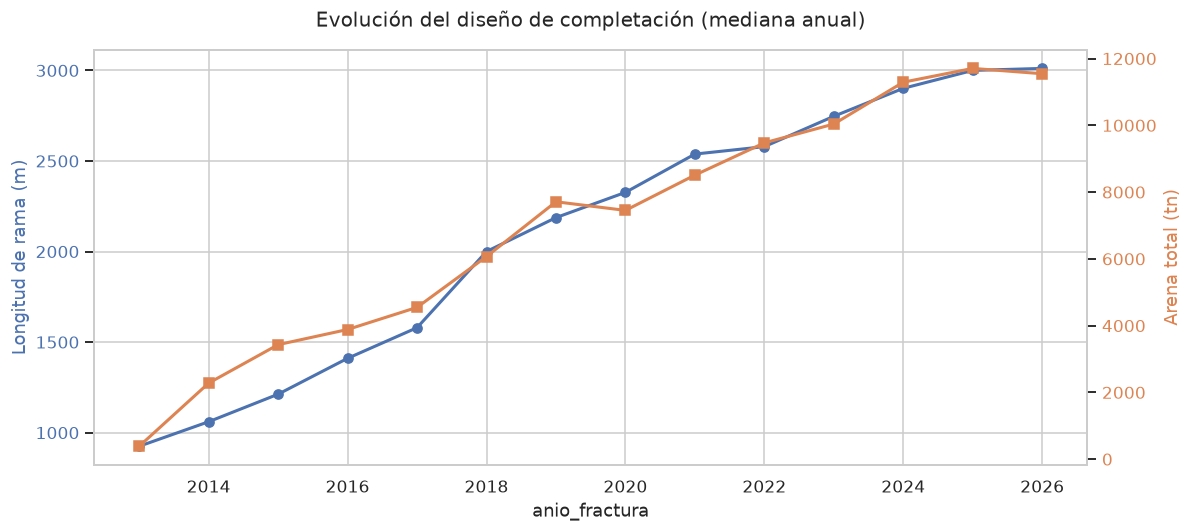

In [28]:
# Visualización con Pandas: dos ejes sobre el mismo gráfico
ax = evolucion["rama"].plot(marker="o", color="#4C72B0", linewidth=2,
                            figsize=(11, 5), legend=False)
ax.set_ylabel("Longitud de rama (m)", color="#4C72B0")
ax.tick_params(axis="y", labelcolor="#4C72B0")
ax.set_xlabel("Año de fractura")

ax2 = evolucion["arena"].plot(secondary_y=True, marker="s", color="#DD8452",
                              linewidth=2, ax=ax, legend=False)
ax2.set_ylabel("Arena total (tn)", color="#DD8452")
ax2.tick_params(axis="y", labelcolor="#DD8452")
ax2.grid(False)

ax.set_title("Evolución del diseño de completación (mediana anual)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

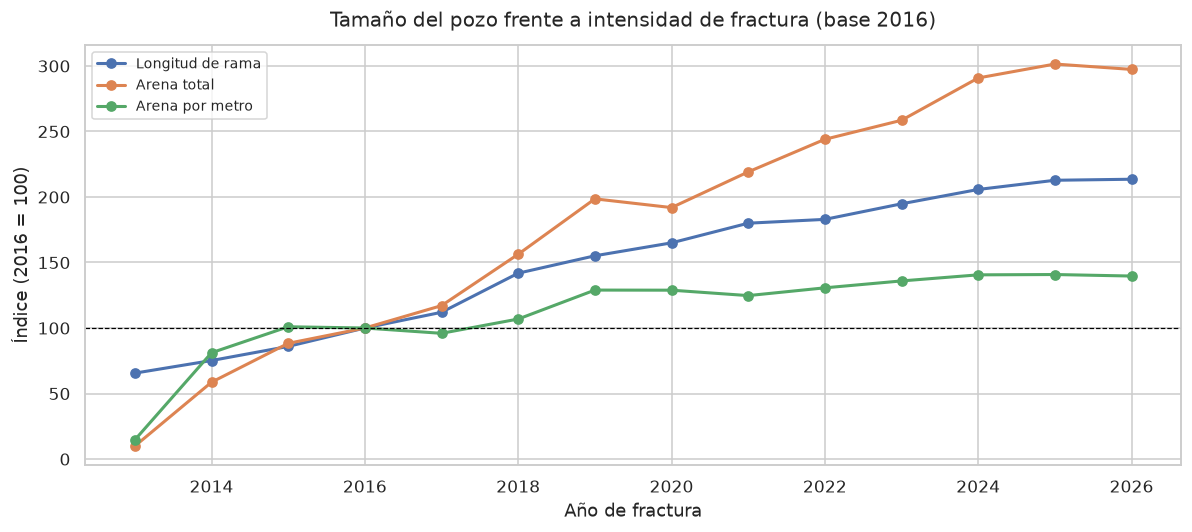

                rama  arena  arena_por_metro
anio_fractura                               
2,016.00      100.00 100.00           100.00
2,019.00      155.00 199.00           129.00
2,025.00      213.00 301.00           141.00


In [29]:
# ¿La intensidad creció al mismo ritmo que el tamaño del pozo?
# Se toma 2016 como base: es el primer año con más de 100 pozos, así que la
# mediana es estable. Usar 2013 (10 pozos) distorsionaría todo el índice.
ANIO_BASE = 2016
columnas_indice = ["rama", "arena", "arena_por_metro"]

base = evolucion.loc[ANIO_BASE, columnas_indice]
normalizado = evolucion[columnas_indice].div(base) * 100

ax = normalizado.plot(figsize=(11, 5), marker="o", linewidth=2)
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel(f"Índice ({ANIO_BASE} = 100)")
ax.set_xlabel("Año de fractura")
ax.set_title(f"Tamaño del pozo frente a intensidad de fractura (base {ANIO_BASE})",
             fontsize=13, pad=12)
ax.legend(["Longitud de rama", "Arena total", "Arena por metro"], fontsize=9)
plt.tight_layout()
plt.show()

print(normalizado.loc[[ANIO_BASE, 2019, 2025]].round(0))

**Hallazgo de negocio.** Los dos gráficos cuentan historias distintas.

Tomando 2016 como base (el primer año con más de 100 pozos, para que la mediana sea estable), entre
2016 y 2025 la arena total por pozo se multiplicó por 3,0. Pero eso es en buena medida un efecto de
escala: la rama se duplicó (x2,1) en el mismo período. Cuando se mira la **intensidad** (arena por
metro de rama), el crecimiento es mucho menor —x1,4— y sobre todo **se aplana desde 2019**: pasa de
3,59 tn/m ese año a 3,92 en 2025, apenas un 9% en seis años.

La industria dejó de responder subiendo la intensidad de fractura y pasó a **alargar el pozo y
apretar el espaciamiento entre etapas** (de 78 m en 2018 a 59 m en 2026). Es exactamente el tipo de
pregunta que el modelo de la Pre-entrega 3 tiene que poder responder: si la intensidad se estancó,
¿es porque llegó a un punto de rendimientos decrecientes?

### 10.2 Distribución de las variables de diseño

Histogramas con Pandas para ver la forma de cada variable.

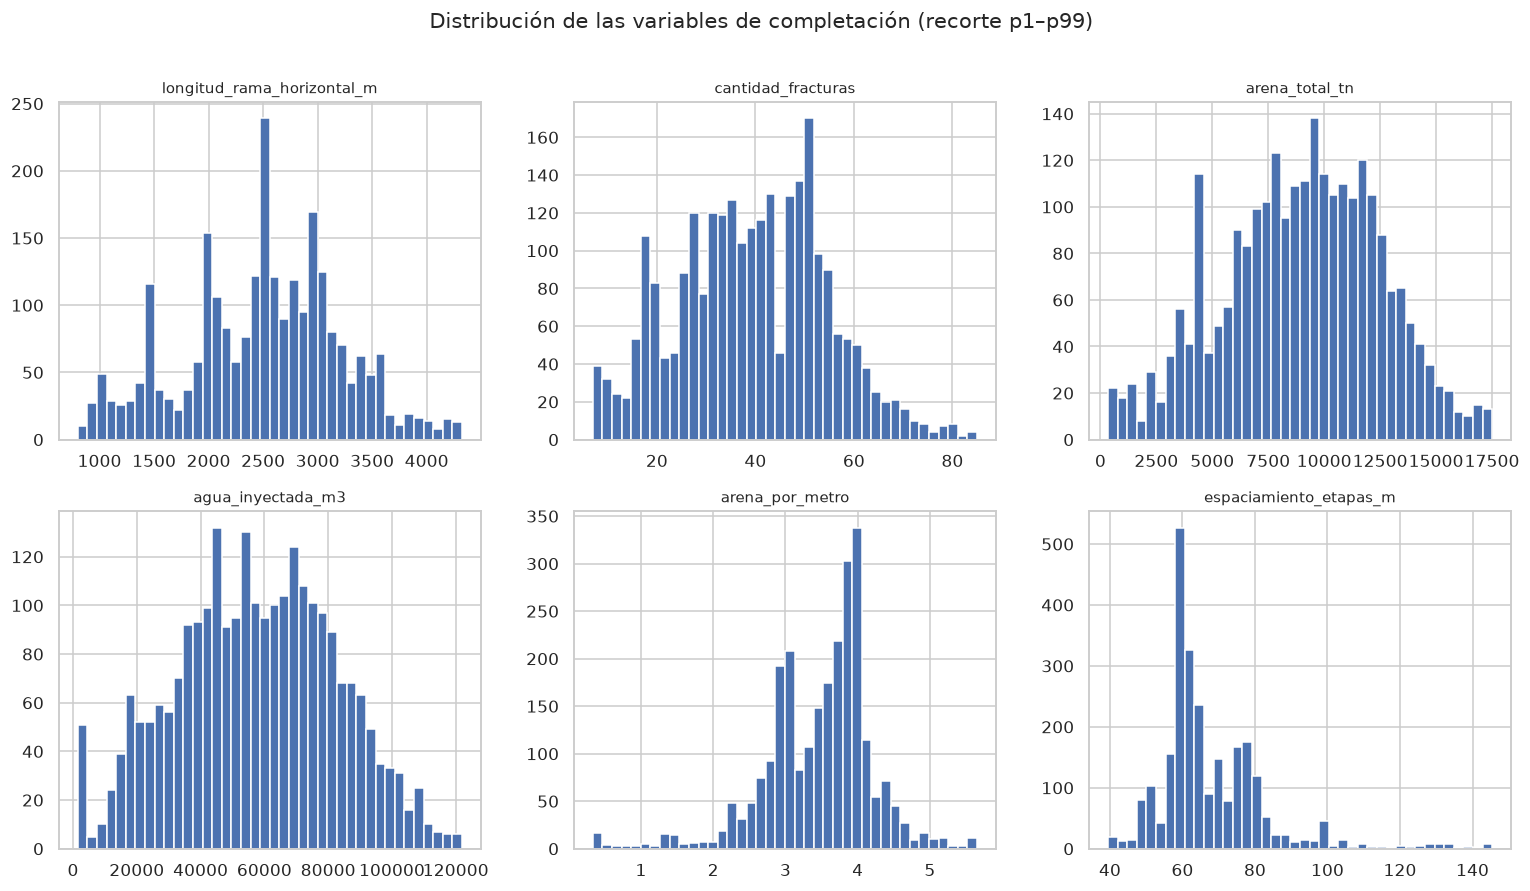

In [30]:
columnas_hist = ["longitud_rama_horizontal_m", "cantidad_fracturas", "arena_total_tn",
                 "agua_inyectada_m3", "arena_por_metro", "espaciamiento_etapas_m"]

# Se recorta la vista al rango entre percentil 1 y 99. Sin esto, las colas de
# arena_por_metro y espaciamiento_etapas_m aplastan el histograma contra el eje
# y no se ve nada. Es un recorte de VISUALIZACIÓN: no altera los datos.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.ravel(), columnas_hist):
    lim_inf, lim_sup = df[col].quantile([0.01, 0.99])
    df.loc[df[col].between(lim_inf, lim_sup), col].plot.hist(
        bins=40, ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")

fig.suptitle("Distribución de las variables de completación (recorte p1–p99)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

`longitud_rama_horizontal_m` es casi simétrica y muestra **picos en valores redondos**: 2.800 m
aparece 34 veces, 2.000 m veintisiete y 1.500 m veintidós, contra una o dos repeticiones de un valor
cualquiera. Solo el 6,6% de los pozos cae en múltiplos exactos de 100, así que la mayoría reporta la
longitud medida; pero esos picos sugieren que una parte se carga contra el objetivo de diseño en
lugar de la medición real.

`arena_por_metro` y `espaciamiento_etapas_m` se concentran en un rango angosto con colas largas
—consistente con un estándar de industria más unos pocos pozos atípicos.

### 10.3 ¿Cuánto se parecen entre sí las variables de diseño?

Antes de modelar hay que saber qué predictores son redundantes.

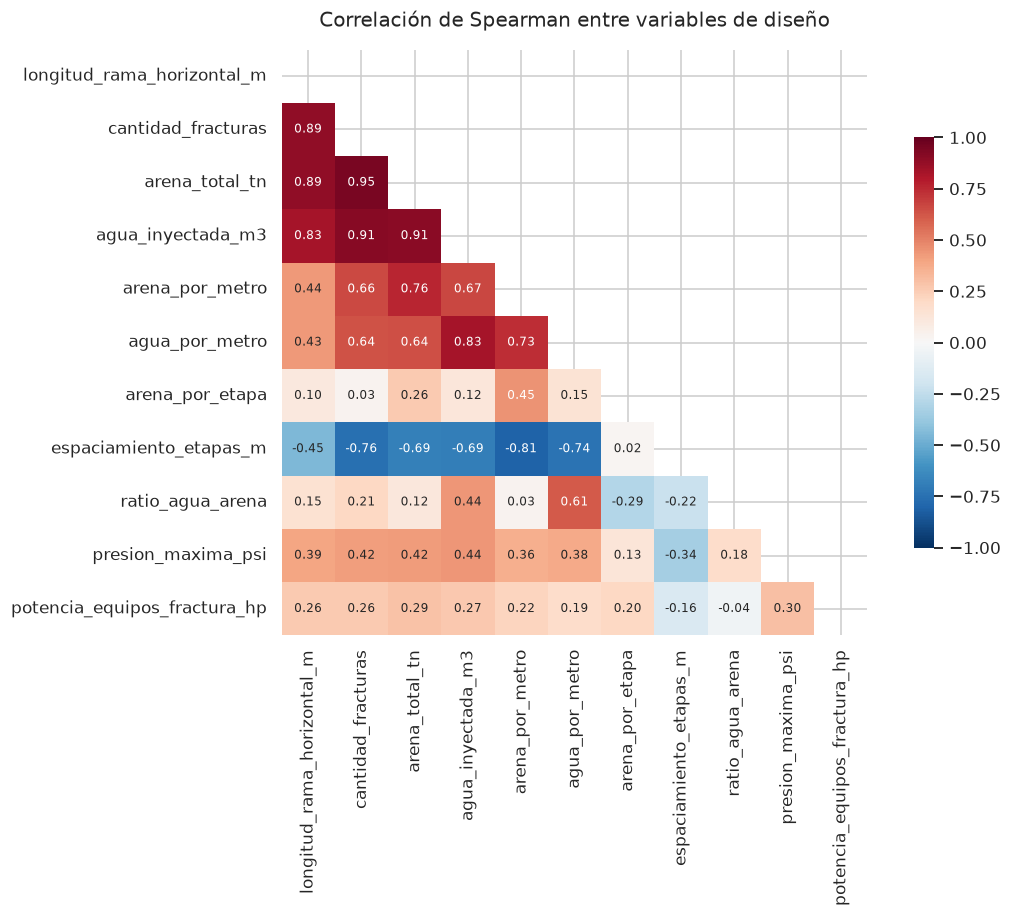

In [31]:
cols_corr = ["longitud_rama_horizontal_m", "cantidad_fracturas", "arena_total_tn",
             "agua_inyectada_m3", "arena_por_metro", "agua_por_metro",
             "arena_por_etapa", "espaciamiento_etapas_m", "ratio_agua_arena",
             "presion_maxima_psi", "potencia_equipos_fractura_hp"]

matriz = df[cols_corr].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 8.5))
mascara = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlación de Spearman entre variables de diseño", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [32]:
# Pares más redundantes
pares = (matriz.where(~np.tril(np.ones(matriz.shape)).astype(bool))
               .stack()
               .sort_values(key=abs, ascending=False)
               .head(8))
pares.to_frame("correlación").rename_axis(["variable_1", "variable_2"])

correlación
variable_1                 variable_2                         
cantidad_fracturas         arena_total_tn                 0.95
                           agua_inyectada_m3              0.91
arena_total_tn             agua_inyectada_m3              0.91
longitud_rama_horizontal_m cantidad_fracturas             0.89
                           arena_total_tn                 0.89
agua_inyectada_m3          agua_por_metro                 0.83
longitud_rama_horizontal_m agua_inyectada_m3              0.83
arena_por_metro            espaciamiento_etapas_m        -0.81

**Hay multicolinealidad severa.** `cantidad_fracturas` y `arena_total_tn` correlacionan 0,95;
`longitud_rama_horizontal_m` con ambas, cerca de 0,89. Tiene sentido físico: un pozo más largo lleva
más etapas y cada etapa consume arena.

Esto tiene dos consecuencias para la Pre-entrega 3:

1. Un modelo lineal con las cuatro variables crudas dará coeficientes inestables e ininterpretables.
   Hay que quedarse con **una variable de escala** (la longitud de rama) más las de **intensidad**
   (arena por metro, espaciamiento), que son casi ortogonales entre sí.
2. La interpretación con SHAP va a repartir el crédito arbitrariamente entre variables
   correlacionadas, así que conviene resolverlo antes y no después.

### 10.4 ¿Cada operadora tiene una estrategia propia de completación?

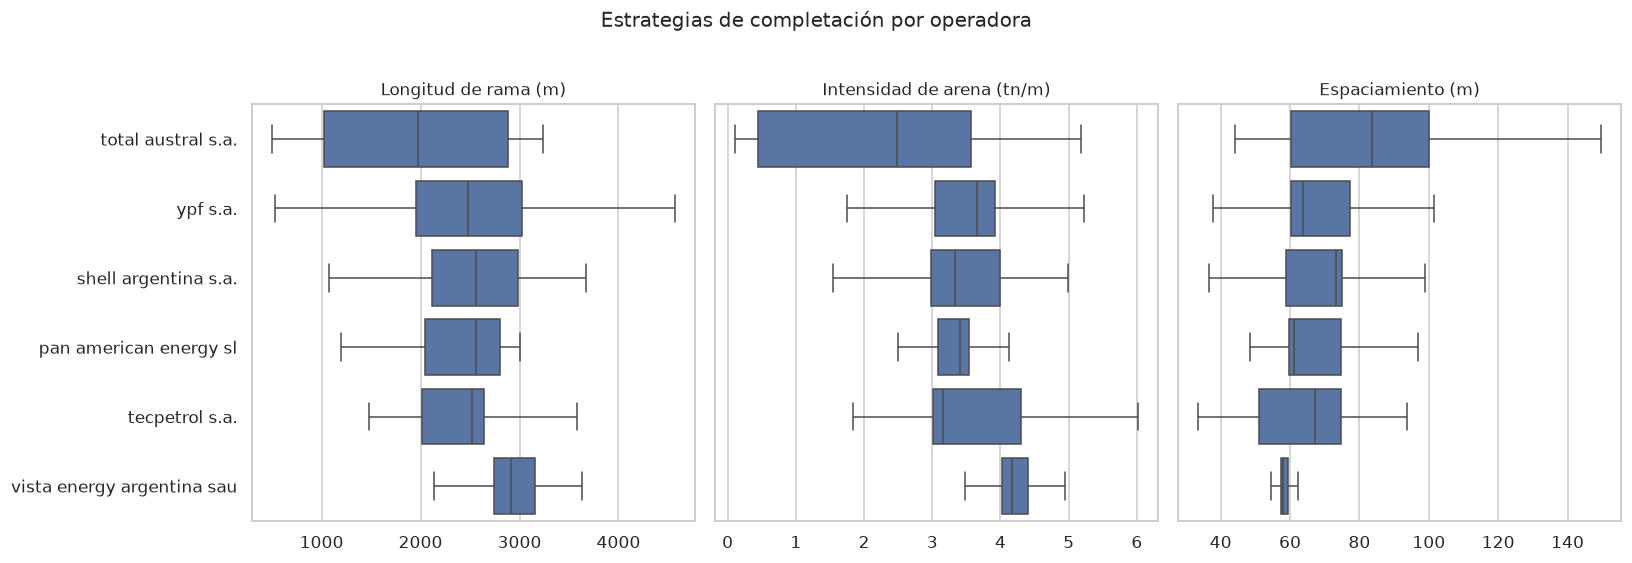

In [33]:
top_empresas = df["empresa_informante"].value_counts().head(6).index
subset_emp = df[df["empresa_informante"].isin(top_empresas)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, titulo in zip(
        axes,
        ["longitud_rama_horizontal_m", "arena_por_metro", "espaciamiento_etapas_m"],
        ["Longitud de rama (m)", "Intensidad de arena (tn/m)", "Espaciamiento (m)"]):
    sns.boxplot(data=subset_emp, y="empresa_informante", x=col, ax=ax, showfliers=False)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

fig.suptitle("Estrategias de completación por operadora", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
(subset_emp.groupby("empresa_informante")
           .agg(pozos=("idpozo", "size"),
                rama=("longitud_rama_horizontal_m", "median"),
                arena_por_metro=("arena_por_metro", "median"),
                espaciamiento=("espaciamiento_etapas_m", "median"))
           .sort_values("arena_por_metro", ascending=False)
           .round(2))

,pozos,rama,arena_por_metro,espaciamiento
empresa_informante,,,,
vista energy argentina sau,154,"2,910.75",4.17,58.00
ypf s.a.,1391,"2,484.00",3.66,63.61
pan american energy sl,119,"2,556.00",3.41,61.22
shell argentina s.a.,175,"2,560.00",3.33,73.20
tecpetrol s.a.,164,"2,515.00",3.16,67.32
total austral s.a.,155,"1,970.00",2.48,83.58


Las estrategias son **claramente distintas**. Vista Energy diseña los pozos más agresivos de la
muestra: la rama mediana más larga (2.911 m), la mayor intensidad de arena (4,17 tn/m) y el
espaciamiento más apretado (58 m). Total Austral está en el otro extremo, con 1.970 m de rama y 2,48
tn/m.

Los boxplots agregan algo que la tabla de medianas esconde: **la dispersión también distingue a las
operadoras**. Vista Energy no solo diseña más agresivo, sino que lo hace de forma muy estandarizada
—sus cajas son angostas en las tres variables—, mientras que Total Austral muestra una dispersión
enorme en intensidad. Una repite una receta; la otra decide pozo por pozo.

Esto es un aviso para el modelado: **la operadora está confundida con el diseño**. Si el modelo usa
`empresa_informante` como predictor, puede estar capturando la calidad del área que cada empresa
opera en lugar del efecto del diseño en sí.

### 10.5 ¿Cómo se reparte la actividad?

Un gráfico de barras con Pandas para dimensionar la concentración del mercado.

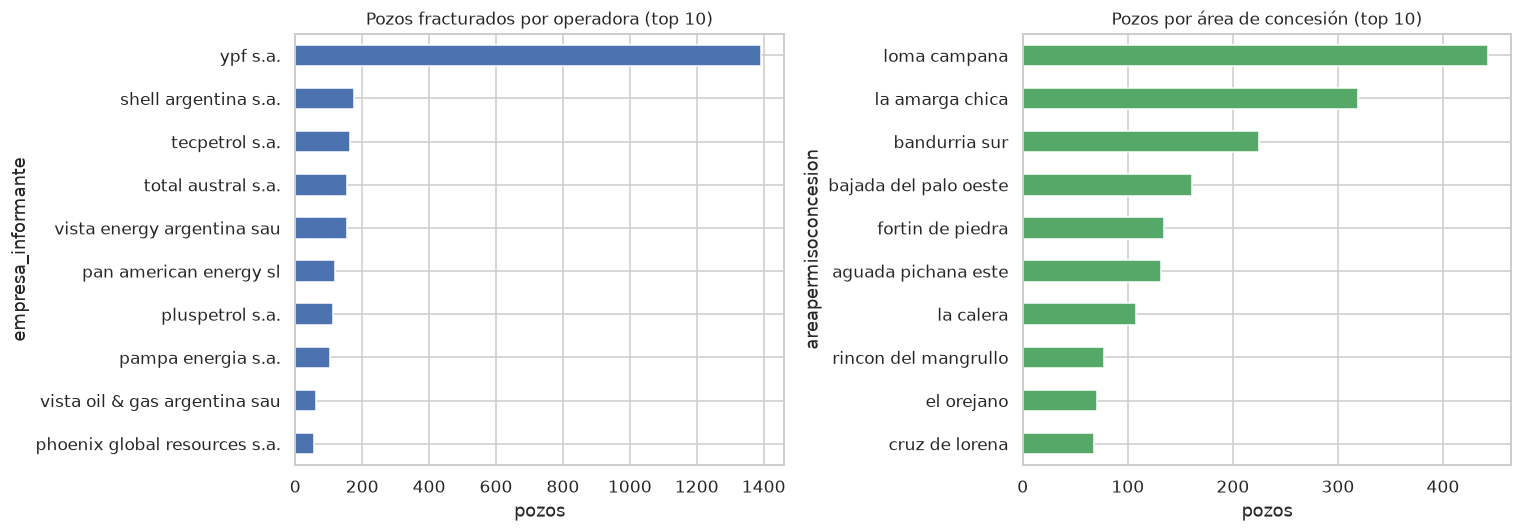

YPF concentra el 53.4% de los pozos del dataset.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

(df["empresa_informante"].value_counts().head(10).sort_values()
   .plot.barh(ax=axes[0], color="#4C72B0"))
axes[0].set_title("Pozos fracturados por operadora (top 10)", fontsize=11)
axes[0].set_xlabel("pozos")

(df["areapermisoconcesion"].value_counts().head(10).sort_values()
   .plot.barh(ax=axes[1], color="#55A868"))
axes[1].set_title("Pozos por área de concesión (top 10)", fontsize=11)
axes[1].set_xlabel("pozos")

plt.tight_layout()
plt.show()

print(f"YPF concentra el {100 * (df['empresa_informante'] == 'ypf s.a.').mean():.1f}% "
      f"de los pozos del dataset.")

**YPF sola concentra más de la mitad de los pozos.** Es el sesgo de representación más importante del
dataset y hay que declararlo: el modelo va a aprender sobre todo la forma de completar de YPF, y sus
predicciones para operadoras chicas van a ser menos confiables.

### 10.6 Intensidad de fractura frente a tamaño del pozo

¿Los pozos más largos se fracturan con la misma intensidad que los cortos?

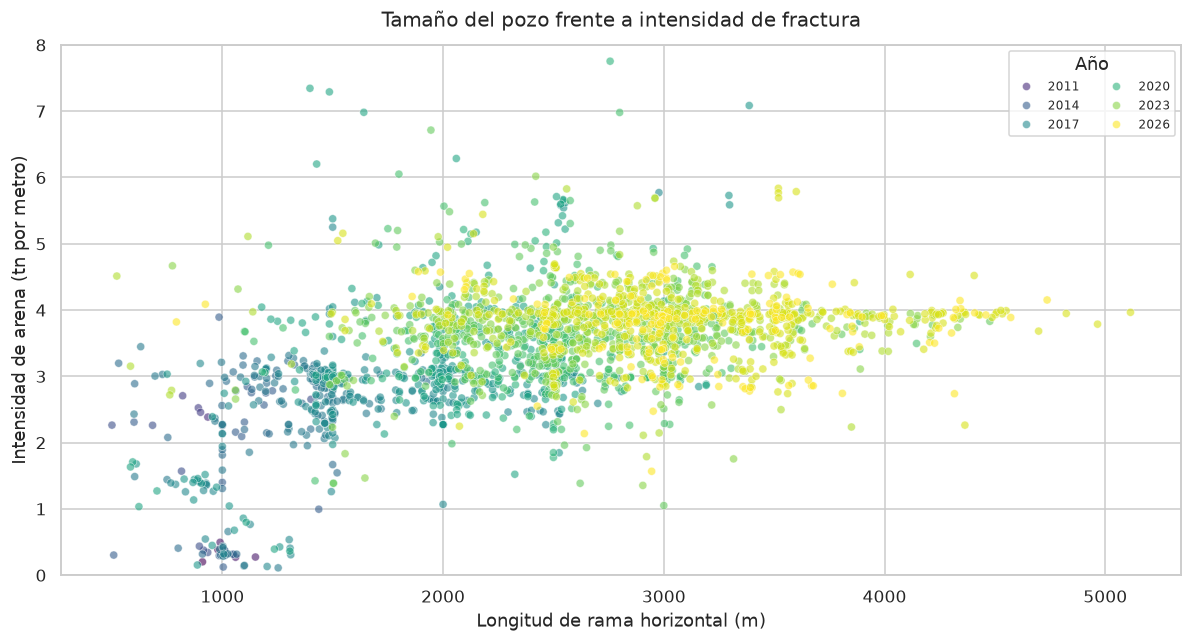

In [36]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(data=df[df["carga_sospechosa"] == 0],
                x="longitud_rama_horizontal_m", y="arena_por_metro",
                hue="anio_fractura", palette="viridis", alpha=0.6, s=28, ax=ax)

ax.set_xlabel("Longitud de rama horizontal (m)")
ax.set_ylabel("Intensidad de arena (tn por metro)")
ax.set_ylim(0, 8)
ax.set_title("Tamaño del pozo frente a intensidad de fractura", fontsize=13, pad=12)
ax.legend(title="Año", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

La nube se desplaza hacia arriba y hacia la derecha con el paso de los años: los pozos son a la vez
más largos y más intensos. Pero dentro de cada año la relación entre longitud e intensidad es débil,
lo que confirma que **son dos decisiones de diseño independientes** y que conviene tratarlas como
predictores separados.

## 11. Enriquecimiento opcional: la variable objetivo

Esta sección construye `prod_pet_acum_12m` cruzando con la tabla de producción (Capítulo IV). Es la
variable que va a predecir el modelo de la Pre-entrega 3.

**Es opcional:** si los archivos de producción no están descargados, el notebook lo informa y sigue
sin fallar. Todo lo anterior ya constituye la entrega.

> Para activarla, descargá dos o tres años de producción del Capítulo IV a `data/`. Buscá los
> archivos que dicen **"con identificador"**, que son los únicos que traen `idpozo`; los de
> "DDJJ abiertas y cerradas" no sirven para el join.
>
> `http://datos.energia.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo`

In [37]:
archivos_produccion = []
for carpeta in CARPETAS_BUSQUEDA:
    archivos_produccion = sorted(glob.glob(str(Path(carpeta) / "*pozos-de-gas-y-petr*.csv")))
    if archivos_produccion:
        break

TIENE_PRODUCCION = len(archivos_produccion) > 0

if TIENE_PRODUCCION:
    print(f"Archivos de producción encontrados: {len(archivos_produccion)}")
    for f in archivos_produccion:
        print("  -", Path(f).name)
else:
    print("No se encontraron archivos de producción.")
    print("La sección 11 queda desactivada; el resto del notebook ya se ejecutó completo.")

No se encontraron archivos de producción.
La sección 11 queda desactivada; el resto del notebook ya se ejecutó completo.


### 11.1 Ventana de los primeros 12 meses

Se define la producción de los **primeros 12 meses de vida de cada pozo**, que es la métrica estándar
de la industria. Comparar producción total le daría ventaja a los pozos más antiguos solo por llevar
más tiempo en actividad.

Dos precauciones metodológicas que conviene explicitar:

1. El mes de vida **no** se calcula con `cumcount()`. Si un pozo tiene meses sin reportar, el conteo
   posicional los saltea y comprime la ventana. Se calcula con la diferencia de períodos contra el
   primer mes con producción efectiva.
2. Se descartan los pozos cuyo primer mes de producción coincide con el inicio del período
   descargado, porque para ellos no se sabe si ese es realmente su primer mes o si venían
   produciendo desde antes (**truncamiento a izquierda**).

In [38]:
if TIENE_PRODUCCION:
    prod = pd.concat([pd.read_csv(f, low_memory=False) for f in archivos_produccion],
                     ignore_index=True)
    print(f"Registros de producción: {len(prod):,}")

    prod["periodo"] = pd.to_datetime(
        prod["anio"].astype(str) + "-" + prod["mes"].astype(str).str.zfill(2) + "-01",
        errors="coerce")
    prod = prod.dropna(subset=["periodo"])

    periodo_min = prod["periodo"].min()
    periodo_max = prod["periodo"].max()
    print(f"Cobertura temporal: {periodo_min:%Y-%m} a {periodo_max:%Y-%m}")

    # Solo meses con producción efectiva de petróleo
    activos = prod[prod["prod_pet"] > 0].copy()

    # Primer mes de producción real de cada pozo
    primer_mes = activos.groupby("idpozo")["periodo"].min().rename("primer_mes")
    activos = activos.join(primer_mes, on="idpozo")

    # Mes de vida por diferencia de períodos (robusto a meses faltantes)
    activos["mes_de_vida"] = (
        (activos["periodo"].dt.year - activos["primer_mes"].dt.year) * 12
        + (activos["periodo"].dt.month - activos["primer_mes"].dt.month) + 1)
else:
    print("Sección desactivada: faltan los archivos de producción.")

Sección desactivada: faltan los archivos de producción.


In [39]:
if TIENE_PRODUCCION:
    ventana = activos[activos["mes_de_vida"].between(1, 12)]

    objetivo = (ventana.groupby("idpozo")
                       .agg(prod_pet_acum_12m=("prod_pet", "sum"),
                            prod_gas_acum_12m=("prod_gas", "sum"),
                            meses_con_produccion=("mes_de_vida", "count"),
                            primer_mes=("primer_mes", "first"))
                       .reset_index())

    # Truncamiento a izquierda: el pozo ya producía antes del período descargado
    trunc_izq = objetivo["primer_mes"] <= periodo_min
    # Truncamiento a derecha: todavía no cumplió 12 meses dentro del período
    trunc_der = (objetivo["primer_mes"]
                 + pd.DateOffset(months=11)) > periodo_max

    print(f"Pozos con producción:              {len(objetivo):,}")
    print(f"  descartados por truncar a izq.:  {trunc_izq.sum():,}")
    print(f"  descartados por truncar a der.:  {trunc_der.sum():,}")

    objetivo = objetivo[~trunc_izq & ~trunc_der]
    print(f"Pozos con ventana de 12 meses válida: {len(objetivo):,}")
else:
    print("Sección desactivada.")

Sección desactivada.


In [40]:
if TIENE_PRODUCCION:
    df_modelo = df.merge(objetivo.drop(columns=["primer_mes"]), on="idpozo", how="inner")

    # Variable objetivo de clasificación: cuartil superior DENTRO de cada formación.
    # Compararlo contra el percentil global penalizaría a las formaciones menos
    # productivas por geología, no por calidad de diseño.
    umbral_formacion = df_modelo.groupby("formacion_productiva")["prod_pet_acum_12m"].transform(
        lambda s: s.quantile(0.75))
    df_modelo["top_tier"] = (df_modelo["prod_pet_acum_12m"] > umbral_formacion).astype(int)
    df_modelo["productividad_por_metro"] = (df_modelo["prod_pet_acum_12m"]
                                            / df_modelo["longitud_rama_horizontal_m"])

    print(f"Dataset de modelado: {df_modelo.shape[0]:,} pozos x {df_modelo.shape[1]} columnas")
    print()
    print(df_modelo["prod_pet_acum_12m"].describe())
else:
    df_modelo = None
    print("Sección desactivada.")

Sección desactivada.


In [41]:
if TIENE_PRODUCCION:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    df_modelo["prod_pet_acum_12m"].plot.hist(bins=50, ax=axes[0], color="#4C72B0")
    axes[0].set_title("Producción acumulada 12 meses")
    axes[0].set_xlabel("m³ de petróleo")

    np.log1p(df_modelo["prod_pet_acum_12m"]).plot.hist(bins=50, ax=axes[1], color="#55A868")
    axes[1].set_title("Misma variable en escala logarítmica")
    axes[1].set_xlabel("log(1 + m³)")

    plt.tight_layout()
    plt.show()

    print(f"Asimetría original:    {df_modelo['prod_pet_acum_12m'].skew():.2f}")
    print(f"Asimetría logarítmica: {np.log1p(df_modelo['prod_pet_acum_12m']).skew():.2f}")
else:
    print("Sección desactivada.")

Sección desactivada.


In [42]:
if TIENE_PRODUCCION:
    correlaciones = (df_modelo[cols_corr + ["prod_pet_acum_12m"]]
                     .corr(method="spearman")["prod_pet_acum_12m"]
                     .drop("prod_pet_acum_12m")
                     .sort_values(key=abs, ascending=False))

    fig, ax = plt.subplots(figsize=(9, 5.5))
    colores = ["#C44E52" if v < 0 else "#55A868" for v in correlaciones.values]
    ax.barh(correlaciones.index, correlaciones.values, color=colores)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Correlación de Spearman con la producción acumulada")
    ax.set_title("¿Qué se asocia más con la productividad?", fontsize=13, pad=12)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(correlaciones.to_frame("correlación"))
else:
    print("Sección desactivada.")

Sección desactivada.


## 12. Conclusiones del EDA

### Calidad de los datos

- **El dataset original mezcla dos poblaciones incomparables.** 2.054 de 4.890 registros (42%) son
  pozos verticales con rama cero, mayoritariamente convencionales; los 2.836 horizontales son
  mayoritariamente no convencionales. Un pozo vertical mediano bombea 0 tn de arena contra 8.576 tn
  del horizontal mediano. Se trabajó solo con los horizontales.
- **Los ceros, no los nulos, son el problema de calidad.** Solo tres columnas tienen nulos
  (`tipo_reservorio`, `subtipo_reservorio` y `potencia_equipos_fractura_hp`), pero hay ceros
  centinela en longitud de rama, presión, potencia y agua inyectada.
- **El grano no es un pozo por fila.** 4.890 filas contra 4.646 pozos: 244 registros excedentes que
  son cargas parciales de una misma operación, no refracturas. Se consolidaron sumando las
  magnitudes aditivas.
- **Hay un valor centinela en la longitud de rama.** El valor 3,0 m se repite 63 veces. Con un
  análisis de sensibilidad se adoptó un umbral de 500 m, que conserva el 92% de los pozos
  horizontales y estabiliza el espaciamiento entre etapas en 63 m.
- **`co2_inyectado_m3` es inútil para este análisis.** Tiene 159 registros con valor positivo, pero
  todos son pozos verticales: dentro de la población horizontal es idénticamente cero. Se eliminó
  después de filtrar, no antes.
- **Hay outliers físicamente imposibles**, como 209.640 psi de presión máxima y 232.159 hp de
  potencia. Se recortaron por percentil 1 y 99 en lugar de eliminar el pozo entero.

**Resultado: 2.603 pozos horizontales limpios**, con 2.590 en Cuenca Neuquina y 2.517 en Vaca Muerta.

### Variables

- Se construyeron 11 variables derivadas de intensidad y composición. Las de intensidad
  (`arena_por_metro`, `espaciamiento_etapas_m`) son las que permiten comparar pozos de distinto
  tamaño.
- **Hay multicolinealidad severa entre las variables crudas:** `cantidad_fracturas` con
  `arena_total_tn` correlaciona 0,95, y ambas con `longitud_rama_horizontal_m` cerca de 0,89. Para el
  modelado hay que quedarse con una variable de escala más las de intensidad.
- `longitud_rama_horizontal_m` es casi simétrica (asimetría ≈ 0) y no conviene transformarla;
  `arena_por_metro` y `espaciamiento_etapas_m` sí mejoran mucho con `log1p`.
- El encoding combina one-hot para las categóricas de baja cardinalidad y frequency encoding para
  las tres de alta cardinalidad, elegido sobre target encoding para no filtrar la variable objetivo.

### Negocio

- **El diseño de pozo cambió radicalmente en una década.** Entre 2013 y 2026 la rama mediana pasó de
  924 a 3.011 m, las etapas de 7 a 53 y la arena total de 385 a 11.544 tn.
- **La intensidad de fractura se amesetó.** La arena por metro creció fuerte hasta 2019 (2,78 tn/m en
  2016, 3,59 en 2019) y desde entonces subió apenas a 3,92 tn/m: un 9% en seis años, contra un 41%
  en los tres anteriores. El crecimiento reciente vino de **alargar el pozo y apretar el
  espaciamiento** (de 78 m en 2018 a 59 m en 2026), no de bombear más arena por metro.
  Sugiere que la industria llegó a un punto de rendimientos decrecientes en intensidad, hipótesis que
  el modelo de la Pre-entrega 3 debería poder contrastar.
- **Cada operadora tiene una estrategia identificable.** Vista Energy usa la rama más larga
  (2.911 m), la mayor intensidad (4,17 tn/m) y el espaciamiento más apretado (58 m); Total Austral
  está en el extremo opuesto (1.970 m y 2,48 tn/m).

### Limitaciones y sesgos

- **Concentración en un solo operador.** YPF concentra el 53% de los pozos. El modelo va a aprender
  sobre todo su forma de completar y será menos confiable para operadoras chicas.
- **Concentración geológica.** El 97% de los pozos son de Vaca Muerta, así que las conclusiones no se
  pueden extrapolar a otras formaciones no convencionales.
- **No hay contrafactual.** El dataset solo contiene pozos efectivamente fracturados: no se puede
  saber qué habría producido un pozo con otro diseño, ni qué pasa con los pozos que no se
  perforaron.
- **Datos preliminares.** La Secretaría de Energía publica estos datos como sujetos a revisión, y el
  año en curso está incompleto.
- **Confusión entre diseño y geología.** Cada operadora trabaja en áreas distintas, así que el efecto
  del diseño está confundido con la calidad de la roca. Es la principal amenaza a la validez causal
  del proyecto y hay que controlarla en el modelado.
- **Sesgo de supervivencia temporal** (cuando se active la sección 11): exigir 12 meses completos de
  producción excluye sistemáticamente a los pozos más recientes, que son justamente los de diseño más
  moderno.

### Próximos pasos hacia la Pre-entrega 3

- Descargar la tabla de producción y activar la sección 11 para construir la variable objetivo.
- Selección final de features resolviendo la multicolinealidad detectada.
- Modelo base de regresión y comparación contra alternativas, con la transformación logarítmica de la
  variable objetivo sobre la mesa.
- Optimización de hiperparámetros e interpretación del modelo.

---

## 13. Guardado del dataset procesado

Se guardan dos versiones: la analítica (legible, con las categóricas como texto) y la codificada
(lista para alimentar un modelo).

In [43]:
OUTPUT_DIR = DATA_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "pozos_analitico.csv", index=False)
df_encoded.to_csv(OUTPUT_DIR / "pozos_encoded.csv", index=False)

print(f"pozos_analitico.csv  ->  {df.shape[0]:,} pozos x {df.shape[1]} columnas")
print(f"pozos_encoded.csv    ->  {df_encoded.shape[0]:,} pozos x {df_encoded.shape[1]} columnas")

if TIENE_PRODUCCION and df_modelo is not None:
    df_modelo.to_csv(OUTPUT_DIR / "pozos_con_objetivo.csv", index=False)
    print(f"pozos_con_objetivo.csv -> {df_modelo.shape[0]:,} pozos x {df_modelo.shape[1]} columnas")

print(f"\nRuta: {OUTPUT_DIR.resolve()}")

pozos_analitico.csv  ->  2,603 pozos x 32 columnas
pozos_encoded.csv    ->  2,603 pozos x 49 columnas

Ruta: /tmp/claude-0/-home-user-PaginaWeb/c51fbcbd-2092-576e-85cd-d4a29ce2afdc/scratchpad/ws/data/processed
